In [35]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import ElasticNet

In [36]:
X_feat_12    = np.load('X_feat_12.npy')
Y_71         = np.load('Y_71.npy')
ENFERMEDADES_71 = np.load('ENFERMEDADES_71.npy', allow_pickle=True).tolist()

# Remplazamos los valores faltantes por la media de cada columna
imputer   = SimpleImputer(strategy='mean')
X_feat_12 = imputer.fit_transform(X_feat_12)

print(f"Shape X_feat_12:  {X_feat_12.shape}")
print(f"Shape Y_71:       {Y_71.shape}")
print(f"Enfermedades:     {len(ENFERMEDADES_71)}")

Shape X_feat_12:  (16984, 459)
Shape Y_71:       (16984, 71)
Enfermedades:     71


In [37]:
X_train, X_test, Y_train, Y_test = train_test_split(X_feat_12, Y_71, test_size=0.2, random_state=42)

#Escalamos los datos para que tengan media 0 y desviacion estandar 1, porque los features tienes escalas muy distintas y puede afectar ya que las features con valores grandes dominarian el aprendizaje.
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (13587, 459) | Test: (3397, 459)


Como ya no tenemos clasificacion binaria, si no que tenemos en una matriz de longitud 71, que tiene la probabilidad entre 0 y 1 de que el paciente tenga esa enfermedad. El modelo ya no aprende clase SÍ/NO sino que aprende a aproximar numeros continuos. Lo que hace el modelo es predecir una probabilidad que se aproxime lo máximo posible.
Por eso, no se usan las metricas de clasificacion clasicas ya que estas requieren convertir las probabilidades en etiquetas binarias mediante un umbral.
Se usan metricas de regresion como el MAE (Error absoluto medio) y el MSE (Error cuadratico medio)

El MAE se calcula porque necesitamos saber cuanto se equivoca el modelo en promedio al predecir esos valores entre 0 y 1. Se interpreta como "de media, el modelo se equivoca un x% en las probabilidades". Trata todos los errores de forma lineal y no exagera los errores grandes 
Medimos el MAE global que mide que tan bien predice el modelo en general todo el vector de 71 enfermedades y el MAE por enfermedad que mide que tan bien predice el modelo cada enfermedad por separado

El MSE se calcula porque necesitamos medir el error entre las probabilidades reales y las predichas, penalizando de forma más fuerte las desviaciones grandes. Se interpreta como una medida de "error cuadratico medio" en las probabilidades, donde errores grandes tienen mucho mayor impacto que errores pequeños. 
El MSE  global mide que tan bien predice el modelo en general de todo el vector de 71 enfermedades, evaluando de forma conjunta el error cuadratico medio en todas las salidas. El MSE por enfermedad mide que tan bien predice el modelo cada enfermedad por separado, permitiendo identificar en que patologías el modelo comete errores más graves o inestables en sus predicciones.

No todos los errores tienen la misma importancia. Queremos que el modelo no solo tenga un error medio bajo, sino evitar tambien evitar predicciones muy alejadas de la probabilidad real. El modelo se ve forzado a evitar predicciones extremadamente incorrectas y a mantener estimaciones más estables y cercanas a las probabilidades reales.

In [38]:
def mostrar_metricas(nombre, Y_true, Y_pred):
    mse_global = mean_squared_error(Y_true, Y_pred)
    mae_global = mean_absolute_error(Y_true, Y_pred)
    print(f"\n--- {nombre} ---")
    print(f"MAE global: {mae_global:.4f} | MSE global: {mse_global:.4f}")
    print(f"\n{'Enfermedad':<12} {'MAE':>6} {'MSE':>6}  {'Pacientes':>10}")#{'R2':>6}
    print("-" * 50)
    for i, enf in enumerate(ENFERMEDADES_71):
        y_true_i    = Y_true[:, i]
        y_pred_i    = Y_pred[:, i]
        n_positivos = (y_true_i > 0).sum()
        if n_positivos < 5:
            continue
        mae_i = mean_absolute_error(y_true_i, y_pred_i)
        mse_i = mean_squared_error(y_true_i, y_pred_i)
        #r2_i  = r2_score(y_true_i, y_pred_i)
        print(f"{enf:<12} {mae_i:>6.3f} {mse_i:>6.3f}  {n_positivos:>10}")#{r2_i:>6.3f}

def mostrar_prediccion_paciente(idx, Y_true, Y_pred, umbral=0.3): #cambiar el valor del umbral
    print(f"\nPaciente {idx}:")
    print(f"{'Enfermedad':<12} {'Real':>6} {'Predicho':>10}")
    print("-" * 32)
    for i, enf in enumerate(ENFERMEDADES_71):
        real = Y_true[idx, i]
        pred = Y_pred[idx, i]
        if real > 0 or pred > umbral:
            print(f"{enf:<12} {real:>6.2f} {pred:>10.2f}")

In [39]:
#Vamos a hacer tres funciones adicionales para intentar ver como de bueno es el modelo

#Medimos el Error Absoluto Medio solo en los casos positivos, solo en los pacientes que realmente tienen esa enfermedad.
#Hay muchos ceros que son faciles de predecir y por tanto tapan los errores importantes
#Responde a "Cuando el paciente tiene la enfermedad, ¿lo estoy midiendo bien?"
def mae_possitives(Y_true, Y_pred, ENFERMEDADES):
    print("\n=== MAE EN CASOS POSITIVOS ===")
    for i, enf in enumerate(ENFERMEDADES):
        y_true_i = Y_true[:, i]
        y_pred_i = Y_pred[:, i]
        
        mask = y_true_i > 0
        
        if mask.sum() < 5:
            continue
        
        mae_i = np.mean(np.abs(y_true_i[mask] - y_pred_i[mask]))
        
        print(f"{enf:<12} MAE+: {mae_i:.4f} | casos: {mask.sum()}")

#Sesgo (subestima o sobreestima) en casos positivos
#Medimos si el model se queda corto o tiende a exagerar en los casos positivos, es decir, cuando el paciente tiene la enfermedad, ¿el modelo predice un valor menor o mayor que el real?
#Sesgo positivo: el modelo tiende a sobreestimar la probabilidad de tener esa enfermedad, lo que puede llevar a falsos positivos.
#Sesgo negativo: el modelo tiende a subestimar la probabilidad de tener esa enfermedad, lo que puede llevar a falsos negativos.
#Sesgo cercano a cero: el modelo no tiene una tendencia clara a sobreestimar o subestimar, lo que es ideal.
def sesgo_prediccion(Y_true, Y_pred, ENFERMEDADES):
    print("\n=== SESGO DE PREDICCIÓN ===")
    
    for i, enf in enumerate(ENFERMEDADES):
        y_true_i = Y_true[:, i]
        y_pred_i = Y_pred[:, i]
        
        mask = y_true_i > 0
        
        if mask.sum() < 5:
            continue
        
        sesgo = np.mean(y_pred_i[mask] - y_true_i[mask])
        
        print(f"{enf:<12} sesgo: {sesgo:.4f}")

#Distribución de errores en casos positivos
#Mirarmos como se reparten los errores y si hay muchos errores grandes o pequeños
#Dos modelos pueden tener el mismo MAE pero uno de ellos puede tener muchos errores pequeños y otro puede tener pocos errores pero muy grandes. Es importante entender esta distribución para mejorar el modelo.
def distribucion_errores(Y_true, Y_pred, ENFERMEDADES, idx):
    errores = Y_pred[:, idx] - Y_true[:, idx]
    
    plt.figure()
    plt.hist(errores, bins=50)
    plt.title(f"Distribución de errores - {ENFERMEDADES[idx]}")
    plt.xlabel("Error (pred - real)")
    plt.ylabel("Frecuencia")
    plt.show()

In [40]:



def ejecutar_ridge(X_train, X_test, Y_train, Y_test, nombre):
    
    print(f"\n=== Ridge Regression — {nombre} ===")
    model = MultiOutputRegressor(Ridge(alpha=10), n_jobs=-1) #Para mejorar el modelo vamos a cambiar el valor de alpha de 1 a 10
    #El ridge regression es una version de regresion lineal que incluye regularizacion . Es como una regresion lineal normal pero con una penalizacion para evitar que el modelo se vuelva demasiado complejo y se sobreajuste a los datos de entrenamiento. La penalizacion se controla con el parametro alpha, que determina la fuerza de la regularizacion. Un alpha mas alto significa una regularizacion mas fuerte, lo que puede ayudar a reducir el sobreajuste pero tambien puede hacer que el modelo sea menos preciso si es demasiado alto.
    #Es una regresion lineal más estable y menos propensa al overfitting, especialmente cuando hay muchas características o multicolinealidad entre ellas. Sin embargo, no captura relaciones no lineales entre las características y el objetivo, lo que puede limitar su rendimiento en algunos casos.
    #El MultiOutputRegressor crea un modelo independiente por cada salida, lo que permite manejar múltiples variables objetivo en un solo modelo. Esto es útil cuando se tienen varias enfermedades a predecir, ya que cada una puede tener su propia relación con las características de entrada.
    #En resumen, todo esto se traduce como voy a entrenar varios modelos Ridge en paralelo, uno por cada enfermedad que quiero predecir
    
    model.fit(X_train, Y_train)

    Y_pred_train = np.clip(model.predict(X_train), 0, 1)
    Y_pred_test  = np.clip(model.predict(X_test),  0, 1)

    mostrar_metricas("Train", Y_train, Y_pred_train)
    mostrar_metricas("Test",  Y_test,  Y_pred_test)
    mae_possitives(Y_test, Y_pred_test, ENFERMEDADES_71)
    sesgo_prediccion(Y_test, Y_pred_test, ENFERMEDADES_71)
    distribucion_errores(Y_test, Y_pred_test, ENFERMEDADES_71, 0)  # Ejemplo para la primera enfermedad
    return model, Y_pred_test

#Como nada mejora vamos a cambiar Ridge por ElasticNet, que es una combinación de Ridge y Lasso, para ver si conseguimos mejorar el modelo. El ElasticNet tiene dos hiperparámetros, alpha y l1_ratio, que controlan la fuerza de la regularización y la mezcla entre Ridge y Lasso
def ejecutar_elasticnet(X_train, X_test, Y_train, Y_test, nombre):
    
    print(f"\n=== ElasticNet Regression — {nombre} ===")
    model = MultiOutputRegressor(ElasticNet(alpha=0.001, l1_ratio=0.5), n_jobs=-1) 
    #El elasticnet es una combinacion de Ridge y Lasso lo que permite mejorar el modelo en casos donde hay muchas características irrelevantes o cuando hay multicolinealidad entre las características. 
    # El alpha controla la fuerza de la regularización, mientras que el l1_ratio controla la mezcla entre Ridge (l1_ratio=0) y Lasso (l1_ratio=1). Al ajustar estos hiperparámetros, podemos encontrar un equilibrio que mejore el rendimiento del modelo.
    
    model.fit(X_train, Y_train)

    Y_pred_train = np.clip(model.predict(X_train), 0, 1)
    Y_pred_test  = np.clip(model.predict(X_test),  0, 1)

    mostrar_metricas("Train", Y_train, Y_pred_train)
    mostrar_metricas("Test",  Y_test,  Y_pred_test)
    mae_possitives(Y_test, Y_pred_test, ENFERMEDADES_71)
    sesgo_prediccion(Y_test, Y_pred_test, ENFERMEDADES_71)
    distribucion_errores(Y_test, Y_pred_test, ENFERMEDADES_71, 0)  # Ejemplo para la primera enfermedad
    return model, Y_pred_test

def ejecutar_random_forest_reg(X_train, X_test, Y_train, Y_test, nombre): #Explicar en la memoria que no es la probabilidad de tener esa enfermedad, sino la probabilidad de que un paciente con esas características tenga esa enfermedad, es decir, la probabilidad de que un paciente parecido a este tenga esa enfermedad. Es una diferencia sutil pero importante.
    #Estamos entrenando un modelo que predice un vector de 71 valores.
    print(f"\n=== Random Forest Regressor — {nombre} ===")
    model = RandomForestRegressor(
        n_estimators=300, #Aumentamos a 800 (antes 300) para mejorar la estabilidad en señales raras, aunque tardará más en entrenar
        max_depth=10, #Cambiamos de 10 a 20 para que no sean tan restrictivo, más capacidad de capturar patrones complejos
        min_samples_leaf=10, #Cambiamos de 10 a 2, menos suavizado mejor deteccion de positivos. De momento volvemos a 10 porque tarda mucho
        #criterion="squared_error",#Añadimos para mejorar el modelo, mas robusto en distribuciones desbalanceadas. Vamos a volver al criterio por defecto porque aumenta muchisimo el timepo de ejecucion
        random_state=42, 
        n_jobs=-1, 
        max_features='sqrt',
    )
    #No predice como tal la probabilidad de tener esa enfermedad, sino que predice un valor entre 0 y 1 que representa la probabilidad de que un paciente de ese grupo tenga esa enfermedad.
    #Por ejemplo, tenemos un grupo de 100 pacientes.
    #10 pacientes con PVC
    #90 pacientes sin PVC
    #En este grupo PVC=0.1
    #Significa que de los pacientes parecidos a este, el 10% tienen PVC.
    #cuando veo un ECG parecido a este, en mis datos históricos solía pasar esto
    model.fit(X_train, Y_train)

    Y_pred_train = np.clip(model.predict(X_train), 0, 1)
    Y_pred_test  = np.clip(model.predict(X_test),  0, 1)

    mostrar_metricas("Train", Y_train, Y_pred_train)
    mostrar_metricas("Test",  Y_test,  Y_pred_test)
    mae_possitives(Y_test, Y_pred_test, ENFERMEDADES_71)
    sesgo_prediccion(Y_test, Y_pred_test, ENFERMEDADES_71)
    distribucion_errores(Y_test, Y_pred_test, ENFERMEDADES_71, 0) 
    return model, Y_pred_test

def ejecutar_hist_gb_reg(X_train, X_test, Y_train, Y_test, nombre):

    print(f"\n=== HistGradientBoosting Regressor — {nombre} ===")

    model = MultiOutputRegressor(HistGradientBoostingRegressor(
        max_depth=6,            # controla complejidad (clave para evitar overfitting)
        learning_rate=0.05,     # aprendizaje más estable
        max_iter=300,           # número de árboles (boosting stages)
        min_samples_leaf=20,    # importante para clases raras
        l2_regularization=0.1,  # ayuda a estabilidad
        random_state=42), 
        n_jobs=-1)

    model.fit(X_train, Y_train)

    Y_pred_train = np.clip(model.predict(X_train), 0, 1)
    Y_pred_test  = np.clip(model.predict(X_test), 0, 1)

    mostrar_metricas("Train", Y_train, Y_pred_train)
    mostrar_metricas("Test",  Y_test,  Y_pred_test)
    mae_possitives(Y_test, Y_pred_test, ENFERMEDADES_71)
    sesgo_prediccion(Y_test, Y_pred_test, ENFERMEDADES_71)
    distribucion_errores(Y_test, Y_pred_test, ENFERMEDADES_71, 0)

    return model, Y_pred_test

def ejecutar_mlp_reg(X_train, X_test, Y_train, Y_test, nombre):
    print(f"\n=== MLP Regressor — {nombre} ===")

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
    Y_train_t = torch.tensor(Y_train, dtype=torch.float32)

    train_loader      = DataLoader(TensorDataset(X_train_t, Y_train_t), batch_size=32, shuffle=True)
    train_eval_loader = DataLoader(TensorDataset(X_train_t, Y_train_t), batch_size=32, shuffle=False)
    test_loader       = DataLoader(TensorDataset(X_test_t,  torch.zeros(len(X_test_t))), batch_size=32, shuffle=False)

    class MLPRegressor(nn.Module):
        def __init__(self, input_size, output_size):
            super().__init__()
            self.red = nn.Sequential(
                nn.Linear(input_size, 256),
                nn.BatchNorm1d(256),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(256, 128),
                nn.BatchNorm1d(128),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(128, 64),
                nn.ReLU(),
                nn.Dropout(0.2),
                nn.Linear(64, output_size),
                nn.Sigmoid()
            )
        def forward(self, x):
            return self.red(x)

    model     = MLPRegressor(input_size=X_train.shape[1], output_size=Y_train.shape[1])
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    EPOCHS    = 100
    PACIENCIA = 15
    mejor_perdida     = float('inf')
    epochs_sin_mejora = 0
    mejor_estado      = None

    for epoch in range(EPOCHS):
        model.train()
        perdida_total = 0
        for X_batch, Y_batch in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(X_batch), Y_batch)
            loss.backward()
            optimizer.step()
            perdida_total += loss.item()

        perdida_media = perdida_total / len(train_loader)
        scheduler.step(perdida_media)

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1}/{EPOCHS} - Pérdida: {perdida_media:.4f} - lr: {optimizer.param_groups[0]['lr']:.6f}")

        if perdida_media < mejor_perdida - 0.0001:
            mejor_perdida     = perdida_media
            epochs_sin_mejora = 0
            mejor_estado      = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            epochs_sin_mejora += 1
            if epochs_sin_mejora >= PACIENCIA:
                print(f"  Early stopping en epoch {epoch+1}")
                break

    model.load_state_dict(mejor_estado)
    model.eval()

    def predecir(loader):
        preds = []
        with torch.no_grad():
            for X_batch, _ in loader:
                preds.append(model(X_batch).numpy())
        return np.clip(np.vstack(preds), 0, 1)

    Y_pred_train = predecir(train_eval_loader)
    Y_pred_test  = predecir(test_loader)

    mostrar_metricas("Train", Y_train, Y_pred_train)
    mostrar_metricas("Test",  Y_test,  Y_pred_test)
    mae_possitives(Y_test, Y_pred_test, ENFERMEDADES_71)
    sesgo_prediccion(Y_test, Y_pred_test, ENFERMEDADES_71)
    distribucion_errores(Y_test, Y_pred_test, ENFERMEDADES_71, 0) 
    return model, Y_pred_test



=== Ridge Regression — Features 12 deriv. ===

--- Train ---
MAE global: 0.0245 | MSE global: 0.0092

Enfermedad      MAE    MSE   Pacientes
--------------------------------------------------
INJLA         0.002  0.000           7
IPLMI         0.006  0.001          31
AFLT          0.010  0.003          43
CLBBB         0.024  0.006         334
CRBBB         0.028  0.007         344
RAO/RAE       0.014  0.005          83
ISCIL         0.017  0.006         118
2AVB          0.002  0.000           6
PACE          0.014  0.002         191
SEHYP         0.005  0.001          25
RVH           0.011  0.003          86
ISCAL         0.056  0.022         429
NDT           0.146  0.067        1167
ANEUR         0.007  0.001          61
INJAS         0.022  0.008         134
DIG           0.018  0.006         116
AFIB          0.008  0.003          39
ALMI          0.025  0.007         183
PAC           0.006  0.002          26
NORM          0.248  0.103        5711
WPW           0.008  0.002 

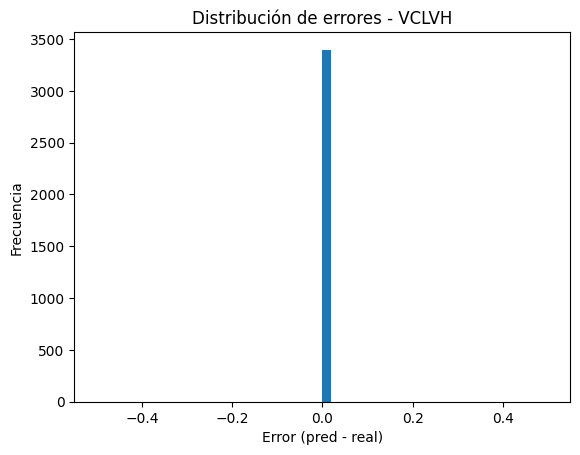


=== ElasticNet Regression — Features 12 deriv. ===

--- Train ---
MAE global: 0.0239 | MSE global: 0.0095

Enfermedad      MAE    MSE   Pacientes
--------------------------------------------------
INJLA         0.001  0.000           7
IPLMI         0.004  0.001          31
AFLT          0.008  0.003          43
CLBBB         0.024  0.006         334
CRBBB         0.029  0.008         344
RAO/RAE       0.012  0.005          83
ISCIL         0.015  0.006         118
2AVB          0.001  0.000           6
PACE          0.014  0.003         191
SEHYP         0.004  0.001          25
RVH           0.010  0.003          86
ISCAL         0.055  0.023         429
NDT           0.147  0.068        1167
ANEUR         0.005  0.002          61
INJAS         0.021  0.008         134
DIG           0.016  0.006         116
AFIB          0.006  0.003          39
ALMI          0.024  0.008         183
PAC           0.004  0.002          26
NORM          0.252  0.105        5711
WPW           0.006  0

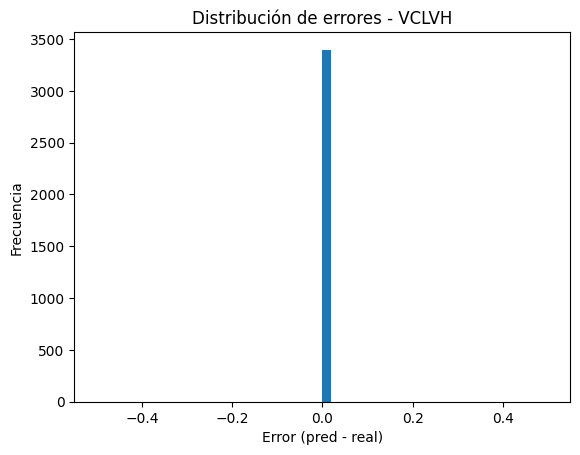

In [41]:
ridge_model, ridge_preds = ejecutar_ridge(X_train, X_test, Y_train, Y_test, "Features 12 deriv.")
#Despues de cambiar el valor de alpha, el modelo no mejora practicamente nada, lo que indica que el modelo no es muy sensible a este hiperparametro. Esto puede ser una señal de que el modelo ya estaba bien regularizado con alpha=1, o que el problema no es el sobreajuste sino la capacidad del modelo para capturar las relaciones entre las características y las enfermedades. 
elasticnet_model, elasticnet_preds = ejecutar_elasticnet(X_train, X_test, Y_train, Y_test, "Features 12 deriv.")



El modelo RIDGE está aprendiendo algo pero está muy sesgado. El modelo aprende que lo seguro es predecir valores bajos cerca de 0. Esto lo que hace es reducir mucho el error medio aunque falle en los casos importantes MAE en positivos (0.5-0.99) en casi todas las enfermedades. Esto quiere decir que cuando la enfermedad está presente, el modelo muchas veces predice 0.1,0.2 pero el valor real es 1.

RESULTADO: no detecta la enfermedad.


=== Random Forest Regressor — Features 12 deriv. ===

--- Train ---
MAE global: 0.0215 | MSE global: 0.0087

Enfermedad      MAE    MSE   Pacientes
--------------------------------------------------
INJLA         0.001  0.000           7
IPLMI         0.003  0.001          31
AFLT          0.006  0.003          43
CLBBB         0.017  0.005         334
CRBBB         0.027  0.009         344
RAO/RAE       0.011  0.005          83
ISCIL         0.014  0.006         118
2AVB          0.001  0.000           6
PACE          0.014  0.005         191
SEHYP         0.003  0.001          25
RVH           0.007  0.003          86
ISCAL         0.050  0.022         429
NDT           0.131  0.059        1167
ANEUR         0.005  0.001          61
INJAS         0.018  0.008         134
DIG           0.014  0.006         116
AFIB          0.005  0.003          39
ALMI          0.018  0.007         183
PAC           0.004  0.002          26
NORM          0.230  0.085        5711
WPW           0.004 

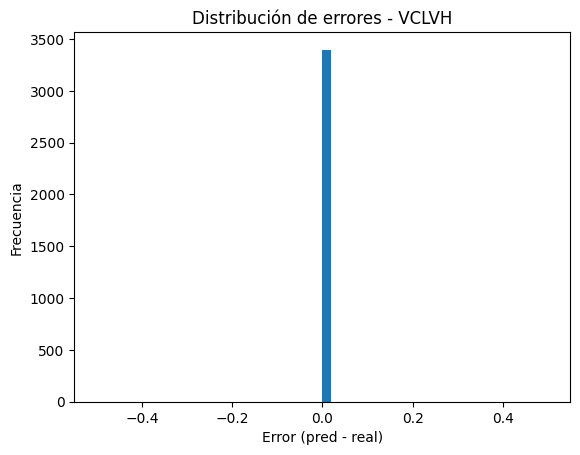

In [42]:
rf_model,    rf_preds    = ejecutar_random_forest_reg(X_train, X_test, Y_train, Y_test, "Features 12 deriv.")


=== HistGradientBoosting Regressor — Features 12 deriv. ===

--- Train ---
MAE global: 0.0139 | MSE global: 0.0049

Enfermedad      MAE    MSE   Pacientes
--------------------------------------------------
INJLA         0.001  0.000           7
IPLMI         0.003  0.001          31
AFLT          0.004  0.002          43
CLBBB         0.007  0.002         334
CRBBB         0.005  0.001         344
RAO/RAE       0.009  0.004          83
ISCIL         0.011  0.004         118
2AVB          0.001  0.000           6
PACE          0.004  0.001         191
SEHYP         0.003  0.001          25
RVH           0.006  0.002          86
ISCAL         0.040  0.015         429
NDT           0.093  0.035        1167
ANEUR         0.004  0.001          61
INJAS         0.013  0.005         134
DIG           0.012  0.005         116
AFIB          0.005  0.002          39
ALMI          0.009  0.002         183
PAC           0.004  0.002          26
NORM          0.146  0.048        5711
WPW          

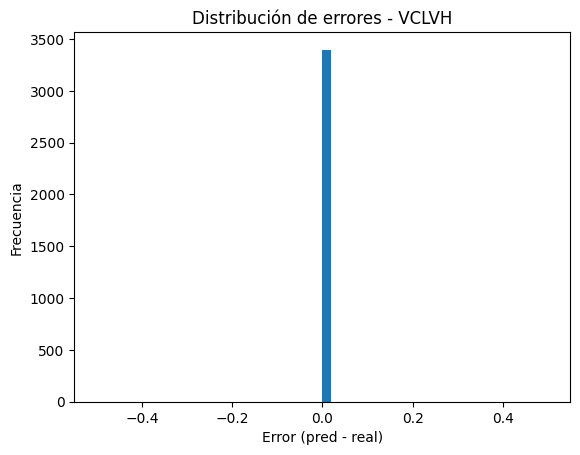

In [43]:
hist_gb_model, hist_gb_preds = ejecutar_hist_gb_reg(X_train, X_test, Y_train, Y_test, "Features 12 deriv.")


=== MLP Regressor — Features 12 deriv. ===
  Epoch 10/100 - Pérdida: 0.0095 - lr: 0.001000
  Epoch 20/100 - Pérdida: 0.0089 - lr: 0.001000
  Epoch 30/100 - Pérdida: 0.0085 - lr: 0.001000
  Epoch 40/100 - Pérdida: 0.0082 - lr: 0.001000
  Epoch 50/100 - Pérdida: 0.0080 - lr: 0.001000
  Epoch 60/100 - Pérdida: 0.0078 - lr: 0.001000
  Epoch 70/100 - Pérdida: 0.0076 - lr: 0.001000
  Epoch 80/100 - Pérdida: 0.0075 - lr: 0.001000
  Epoch 90/100 - Pérdida: 0.0073 - lr: 0.001000
  Epoch 100/100 - Pérdida: 0.0073 - lr: 0.001000

--- Train ---
MAE global: 0.0119 | MSE global: 0.0056

Enfermedad      MAE    MSE   Pacientes
--------------------------------------------------
INJLA         0.001  0.000           7
IPLMI         0.002  0.001          31
AFLT          0.002  0.001          43
CLBBB         0.002  0.001         334
CRBBB         0.004  0.002         344
RAO/RAE       0.006  0.005          83
ISCIL         0.011  0.006         118
2AVB          0.000  0.000           6
PACE          0.0

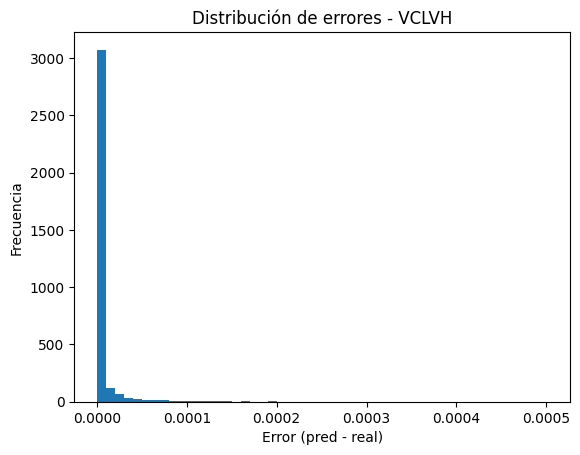

In [44]:
mlp_model,   mlp_preds   = ejecutar_mlp_reg(X_train, X_test, Y_train, Y_test, "Features 12 deriv.")

In [45]:
#print("=== Predicciones MLP ===")
#for idx in [2802,538,111]:
#    mostrar_prediccion_paciente(idx, Y_test, mlp_preds)

In [46]:
print("=== Predicciones Ridge Regressor ===")
for idx in [2802,538,111]:
    mostrar_prediccion_paciente(idx, Y_test, ridge_preds)

=== Predicciones Ridge Regressor ===

Paciente 2802:
Enfermedad     Real   Predicho
--------------------------------
CLBBB          1.00       1.00
ANEUR          0.50       0.01
ASMI           1.00       0.25
IMI            0.50       0.22

Paciente 538:
Enfermedad     Real   Predicho
--------------------------------
PSVT           1.00       0.03
PVC            1.00       0.13

Paciente 111:
Enfermedad     Real   Predicho
--------------------------------
ASMI           0.00       0.60
ISC_           1.00       0.40
LVH            1.00       0.41


In [47]:
print("=== Predicciones Random Forest ===")
for idx in [2802,538,111]:
    mostrar_prediccion_paciente(idx, Y_test, rf_preds)

=== Predicciones Random Forest ===

Paciente 2802:
Enfermedad     Real   Predicho
--------------------------------
CLBBB          1.00       0.77
ANEUR          0.50       0.00
ASMI           1.00       0.05
IMI            0.50       0.03

Paciente 538:
Enfermedad     Real   Predicho
--------------------------------
NORM           0.00       0.31
PSVT           1.00       0.01
PVC            1.00       0.13

Paciente 111:
Enfermedad     Real   Predicho
--------------------------------
ASMI           0.00       0.36
ISC_           1.00       0.37
LVH            1.00       0.40


In [48]:
def mostrar_paciente_completo(idx, Y_test, Y_pred, modelo_nombre):
    print(f"\n{'='*50}")
    print(f"Paciente {idx} — Predicción {modelo_nombre}")
    print(f"{'='*50}")
    print(f"\n{'Enfermedad':<12} {'Probabilidad real':>18} {'Probabilidad pred':>18} {'Diferencia':>12}")
    print("-" * 65)
    
    for i, enf in enumerate(ENFERMEDADES_71):
        real = Y_test[idx, i]
        pred = Y_pred[idx, i]
        if real > 0.01 or pred > 0.2:  # mostramos las relevantes
            diff = pred - real
            signo = "+" if diff > 0 else ""
            print(f"{enf:<12} {real:>18.2f} {pred:>18.2f} {signo}{diff:>11.2f}")

# Probamos con tres pacientes distintos
for idx in [0, 5, 10]:
    mostrar_paciente_completo(idx, Y_test, mlp_preds, "MLP")


Paciente 0 — Predicción MLP

Enfermedad    Probabilidad real  Probabilidad pred   Diferencia
-----------------------------------------------------------------
NORM                       1.00               0.97       -0.03

Paciente 5 — Predicción MLP

Enfermedad    Probabilidad real  Probabilidad pred   Diferencia
-----------------------------------------------------------------
NORM                       0.80               0.84 +       0.04

Paciente 10 — Predicción MLP

Enfermedad    Probabilidad real  Probabilidad pred   Diferencia
-----------------------------------------------------------------
PACE                       1.00               1.00       -0.00


In [49]:
import random
import numpy as np
import torch

def diagnosticar_paciente_nuevo(idx, X_test, Y_test, model, ENFERMEDADES_71, umbral=0.3):
    print(f"\n{'='*55}")
    print(f"  INFORME DE DIAGNÓSTICO — PACIENTE #{idx}")
    print(f"{'='*55}")
    
    # 🔵 Detectar tipo de modelo y predecir correctamente
    if hasattr(model, "eval"):  # 👉 modelo PyTorch (MLP)
        x = torch.tensor(X_test[idx:idx+1], dtype=torch.float32)
        model.eval()
        with torch.no_grad():
            pred = model(x).numpy()[0]
    else:  # 👉 modelo sklearn (RF, Ridge, etc.)
        pred = model.predict(X_test[idx:idx+1])[0]
    
    # 🔵 Seguridad: asegurar rango [0,1]
    pred = np.clip(pred, 0, 1)

    # Separamos en detectadas y no detectadas
    detectadas    = [(ENFERMEDADES_71[i], pred[i]) for i in range(len(ENFERMEDADES_71)) if pred[i] >= umbral]
    no_detectadas = [(ENFERMEDADES_71[i], pred[i]) for i in range(len(ENFERMEDADES_71)) if pred[i] < umbral and pred[i] > 0.05]
    
    # Ordenamos por probabilidad descendente
    detectadas    = sorted(detectadas,    key=lambda x: -x[1])
    no_detectadas = sorted(no_detectadas, key=lambda x: -x[1])
    
    # Enfermedades detectadas
    if detectadas:
        print(f"\n  Enfermedades detectadas (prob >= {umbral}):")
        print(f"  {'Enfermedad':<12} {'Probabilidad':>14} {'Barra'}")
        print(f"  {'-'*45}")
        for enf, prob in detectadas:
            barra = '█' * int(prob * 20)
            print(f"  {enf:<12} {prob:>13.1%}  {barra}")
    else:
        print(f"\n  No se detectaron enfermedades con probabilidad >= {umbral}")

    # Señales débiles
    if no_detectadas:
        print(f"\n  Señales débiles (prob entre 5% y {int(umbral*100)}%):")
        print(f"  {'Enfermedad':<12} {'Probabilidad':>14}")
        print(f"  {'-'*30}")
        for enf, prob in no_detectadas[:5]:
            print(f"  {enf:<12} {prob:>13.1%}")

    # Diagnóstico real
    real = [(ENFERMEDADES_71[i], Y_test[idx, i]) for i in range(len(ENFERMEDADES_71)) if Y_test[idx, i] > 0]
    real = sorted(real, key=lambda x: -x[1])
    
    print(f"\n  {'─'*45}")
    print(f"  Diagnóstico real (oculto al modelo):")
    for enf, prob in real:
        print(f"  {enf:<12} {prob:>13.1%}")
    
    print(f"{'='*55}\n")


# Elegimos 3 pacientes interesantes del test
# Buscamos pacientes con varias enfermedades para que sea más ilustrativo
pacientes_interesantes = []
for idx in range(len(Y_test)):
    n_enfermedades = (Y_test[idx] > 0.5).sum()
    if n_enfermedades >= 2:
        pacientes_interesantes.append(idx)

# Mostramos 3 pacientes aleatorios con varias enfermedades
random.seed(2)
seleccionados = random.sample(pacientes_interesantes, 3)

for idx in seleccionados:
    diagnosticar_paciente_nuevo(idx, X_test, Y_test, mlp_model, ENFERMEDADES_71, umbral=0.3)
    


  INFORME DE DIAGNÓSTICO — PACIENTE #273

  Enfermedades detectadas (prob >= 0.3):
  Enfermedad     Probabilidad Barra
  ---------------------------------------------
  PVC                  96.0%  ███████████████████

  ─────────────────────────────────────────────
  Diagnóstico real (oculto al modelo):
  AMI                 100.0%
  PVC                 100.0%


  INFORME DE DIAGNÓSTICO — PACIENTE #450

  Enfermedades detectadas (prob >= 0.3):
  Enfermedad     Probabilidad Barra
  ---------------------------------------------
  CRBBB                66.7%  █████████████
  IMI                  54.8%  ██████████
  IRBBB                30.7%  ██████

  Señales débiles (prob entre 5% y 30%):
  Enfermedad     Probabilidad
  ------------------------------
  RVH                   9.4%
  1AVB                  7.8%

  ─────────────────────────────────────────────
  Diagnóstico real (oculto al modelo):
  RVH                 100.0%
  IRBBB               100.0%
  IMI                  50.0%


  INF

In [50]:
for idx in seleccionados:
    diagnosticar_paciente_nuevo(idx, X_test, Y_test,rf_model, ENFERMEDADES_71, umbral=0.3)


  INFORME DE DIAGNÓSTICO — PACIENTE #273

  Enfermedades detectadas (prob >= 0.3):
  Enfermedad     Probabilidad Barra
  ---------------------------------------------
  PVC                  64.6%  ████████████

  Señales débiles (prob entre 5% y 30%):
  Enfermedad     Probabilidad
  ------------------------------
  LVH                  18.6%
  ISC_                 14.8%
  NORM                 13.6%
  ASMI                 12.0%
  IMI                   9.3%

  ─────────────────────────────────────────────
  Diagnóstico real (oculto al modelo):
  AMI                 100.0%
  PVC                 100.0%


  INFORME DE DIAGNÓSTICO — PACIENTE #450

  Enfermedades detectadas (prob >= 0.3):
  Enfermedad     Probabilidad Barra
  ---------------------------------------------
  CRBBB                41.0%  ████████

  Señales débiles (prob entre 5% y 30%):
  Enfermedad     Probabilidad
  ------------------------------
  IRBBB                23.2%
  IMI                  16.9%
  NORM                

In [51]:
for idx in seleccionados:
    diagnosticar_paciente_nuevo(idx, X_test, Y_test, ridge_model, ENFERMEDADES_71, umbral=0.3)


  INFORME DE DIAGNÓSTICO — PACIENTE #273

  Enfermedades detectadas (prob >= 0.3):
  Enfermedad     Probabilidad Barra
  ---------------------------------------------
  PVC                  95.0%  ███████████████████
  LVH                  32.4%  ██████

  Señales débiles (prob entre 5% y 30%):
  Enfermedad     Probabilidad
  ------------------------------
  ISC_                 28.1%
  IMI                  20.6%
  NORM                 19.2%
  1AVB                 10.7%
  ASMI                  9.8%

  ─────────────────────────────────────────────
  Diagnóstico real (oculto al modelo):
  AMI                 100.0%
  PVC                 100.0%


  INFORME DE DIAGNÓSTICO — PACIENTE #450

  Enfermedades detectadas (prob >= 0.3):
  Enfermedad     Probabilidad Barra
  ---------------------------------------------
  CRBBB                39.8%  ███████
  IRBBB                33.0%  ██████
  IMI                  31.6%  ██████

  Señales débiles (prob entre 5% y 30%):
  Enfermedad     Probabili